In [1]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
import shutil

# So the Jupyter kernel finds LaTeX when started from Cursor/VS Code
if not shutil.which('pdflatex'):
    os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ.get('PATH', '')

# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

# params_model_shear.yaml contains fiducial values and prior ranges
with open("params_model_shear.yaml", "r") as file:
    fiducials = yaml.safe_load(file)
print(shutil.which("latex"))

/Library/TeX/texbin/latex


In [2]:
import os

# Inject TeX into PATH for this Python process
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import shutil
print("Latex seen by Python:", shutil.which("latex"))

#import matplotlib.pyplot as plt
#plt.rcParams["text.usetex"] = True

Latex seen by Python: /Library/TeX/texbin/latex


In [3]:
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

plt.ioff()  # prevent post-execute redraws that can trigger LaTeX errors in callbacks

# Use matplotlib's built-in text (no LaTeX required)
from matplotlib import rc
rc('text', usetex=False)
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif']})


In [4]:
# LaTeX diagnostic for matplotlib (usetex=True) and Computer Modern (cmr10.tfm)
import shutil
import subprocess

pdflatex = shutil.which("pdflatex")
kpsewhich = shutil.which("kpsewhich")
cmr10_path = None
if kpsewhich:
    try:
        out = subprocess.run([kpsewhich, "cmr10.tfm"], capture_output=True, text=True, timeout=5)
        cmr10_path = out.stdout.strip() if out.returncode == 0 else None
    except Exception:
        pass

print("pdflatex:", pdflatex or "NOT FOUND")
print("kpsewhich:", kpsewhich or "NOT FOUND")
print("cmr10.tfm:", cmr10_path or "NOT FOUND")

if not pdflatex:
    print("\n>>> Fix: Install MacTeX or BasicTeX, then restart Jupyter from a Terminal where 'which pdflatex' works.")
    print("    macOS: brew install --cask basictex  OR  download MacTeX from https://tug.org/mactex/")
    print("    Then run: eval \"$(/usr/libexec/path_helper)\"  and start Jupyter from that terminal.")
elif not cmr10_path:
    print("\n>>> Fix: Install the Computer Modern font package. In Terminal run:")
    print("    sudo tlmgr install cm")
    print("    Then re-run this notebook (and restart the kernel if needed).")
else:
    print("\n>>> LaTeX and cmr10.tfm are available. If figures still fail, restart the Jupyter kernel and re-run.")

pdflatex: /Library/TeX/texbin/pdflatex
kpsewhich: /Library/TeX/texbin/kpsewhich
cmr10.tfm: /usr/local/texlive/2025basic/texmf-dist/fonts/tfm/public/cm/cmr10.tfm

>>> LaTeX and cmr10.tfm are available. If figures still fail, restart the Jupyter kernel and re-run.


In [5]:
#chain, derived, weights, logl, param_names,derived_names,logz,chain_time, chain_time_hms, fiducial
fiducials  = {}
fiducials['H0'] = 67.66
fiducials['ns'] = 0.9665
fiducials['h'] = fiducials['H0']/100.
fiducials['logAs'] = np.log(1e10*2.e-9)
fiducials['Omega_m0'] = 0.311049
fiducials['Omega_b0'] = 0.04897468161869667
fiducials['w0'] = -0.9001
fiducials['wa'] = -0.2025
fiducials['Ads'] = 100.*(1.+fiducials['w0'])
fiducials['Ads_piv'] = 100.*(1.+fiducials['w0']+fiducials['wa']*(1-0.6929))
fiducials['wpiv'] = +fiducials['w0']+fiducials['wa']*(1-0.6929)

In [29]:
# List of MCMC chain files to compare
file_paths = [
    '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_dakar_darkscattering_onlyw0waAds_300600.npz',
     '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_dakar_darkscattering_onlycosmo_300600.npz',
    #'../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_dakar_darkscattering_onlycosmo_500900.npz',
#'../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_covmat_TR1v1.1_dakar_darkscattering_onlycosmo.npz'
 ]  


n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain_npz = np.load(file_path, allow_pickle=True)
        
    
    # Store chain data and parameter names
    chains_info[i] = {}
    print(chain_npz['param_names'])
    chains_info[i]['chain'] = np.vstack([chain_npz['chain'].flat[0][par] for par in chain_npz['param_names']]).T
    chains_info[i]['chain'] = np.hstack((chains_info[i]['chain'], chain_npz['derived'].flat[0]['sigma8_0'][:, np.newaxis]))
    print(chains_info[i]['chain'].shape)
    chains_info[i]['weights'] = chain_npz['weights']
    chains_info[i]['logl'] = chain_npz['logl']
    chains_info[i]['pars'] = np.hstack((chain_npz['param_names'], np.array(['sigma8_0'])))
    chains_info[i]['fiducial'] = chain_npz['fiducial'].flat[0]


['w0' 'wa' 'Ads_piv']
(12276, 4)
['Omega_m0' 'Omega_b0' 'H0' 'logAs' 'ns' 'w0' 'wa' 'Ads_piv']
(15376, 9)


In [30]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    samples.append(
        getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = chains_info[i]['chain'],
            # Parameter names
            names = [i for i in chains_info[i]['pars']],
            # Sample weights (exponential of log-likelihood)
            weights=np.exp(chains_info[i]['weights']),
            # LaTeX labels for parameters (from params_dic)
            labels = [params_dic[p] for p in chains_info[i]['pars']],
            # Smoothing settings for 1D and 2D distributions
            settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
            # Parameter ranges for plotting
            #ranges = Ranges
        ) 
    )
    mnu = chains_info[i]['fiducial']['mnu']
    # Get parameter object (unused but kept for compatibility)
    p = samples[i].getParams() 
    #samples[i].addDerived(p.H0/100., 'h','h')
    #p = samples[i].getParams() 
    #samples[i].addDerived((p.omch2+p.ombh2+mnu/93.14)/p.h**2, 'Omega_m','\Omega_{\\rm m}')
    #p = samples[i].getParams() 
    #samples[i].addDerived(p.sigma8_0*np.sqrt(p.Omega_m/0.3), 'S8', 'S_8')
    #p = samples[i].getParams() 
    a_piv = 0.6929
    samples[i].addDerived(p.Ads_piv*(1.+p.w0)/(1.+p.w0+p.wa*(1-a_piv)), name='Ads', label=r'A_{\rm ds}')
    samples[i].addDerived(p.w0+p.wa*(1-a_piv), name='wpiv', label=r'w_\bar{a}')


Removed no burn in
Removed no burn in


In [31]:
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame


In [32]:
ModelPars = ['Omega_m0', 'Omega_b0', 'logAs', 'H0','ns', 'w0', 'wa', 'Ads_piv', 'wpiv', 'Ads']
ModelPars = ['w0', 'wa', 'Ads_piv', 'wpiv', 'Ads']

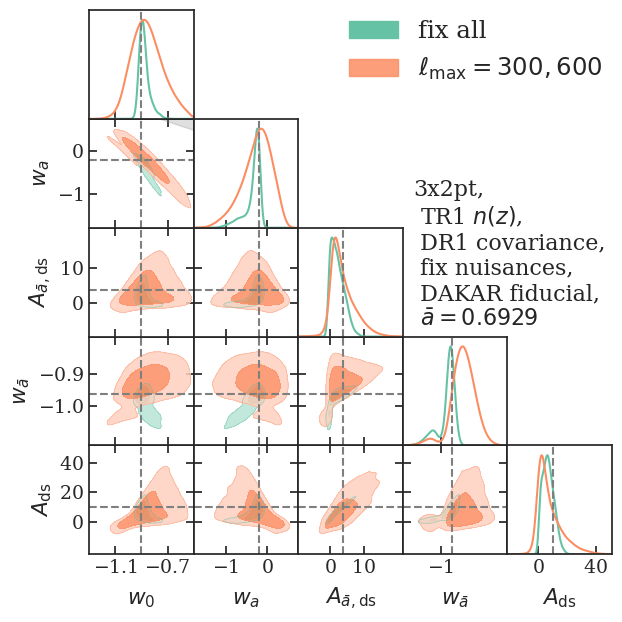

In [33]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================
# Legend labels for each chain (LaTeX formatting supported)
legend_labels = [
    'fix all',
    '$\ell_{\\rm max}=300, 600$',
#    '$\ell_{\\rm max}=900, 500$',
#'$\ell_{\\rm max}=1500, 750$'
]
# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':False, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)


xx=np.linspace(-1.3, -0.5, 126)
if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=1.5, color='tab:gray', linestyle='--')
                if ModelPars[i] == 'wa' and ModelPars[j] == 'w0':
                    #ax.plot(xx, -xx, color='tab:gray', linestyle='--')
                    ax.fill_between(xx, -xx, np.ones(len(xx))*4, color='grey', alpha=0.25)
                    ax.set_xlim(-1.3, -0.5) 
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=1.5, color='tab:gray', linestyle='--')

            # if i==4 and j==3:
            #     ax.set_xlim(-2., 0.5) 

            # if i==4 and j==0:
            #     ax.set_xlim(0.26, 0.37) 
            # if i==4 and j==2: 
            #     ax.set_ylim(-50, 60)
            #     ax.set_xlim(-1.3, -0.5)
            #     y_min, y_max = ax.get_ylim()
            #     ax.fill_between(
            #         xx,
            #         y_min, 
            #         y_max,
            #         facecolor='grey',  #'#F0E6DA',  #'lightgrey',
            #         alpha=0.25,
            #         edgecolor='grey',
            #         linewidth=2, zorder=0
            #     )
            #     ax.fill_between(
            #         xx,
            #         (1.+xx)*150,
            #         facecolor='white',zorder=0,
            #         edgecolor='grey', linewidth=1, linestyle='-'
            #     ) 


# Position for annotation (subplot index)
num = 2
annotation_text = '3x2pt,\n TR1 $n(z)$,\n DR1 covariance,\n fix nuisances,\n DAKAR fiducial,\n $\\bar{a}={0.6929}$'
# Add text annotation to a specific subplot
ax = g.subplots[num, num]
ax.annotate(annotation_text, (1.1, 0.1), xycoords='axes fraction', 
           clip_on=False, fontsize=16) 
plt.show()